In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
from sklearn.datasets import make_moons
x,y= make_moons(n_samples=1000,noise=0.2)
df = {"x1":x[:,0],"x2":x[:,1],"y":y}
dataset = pd.DataFrame(df)
dataset.head(3)

,x1,x2,y
0,-0.291778,1.217439,0
1,0.396745,-0.247396,1
2,0.535584,0.951498,0


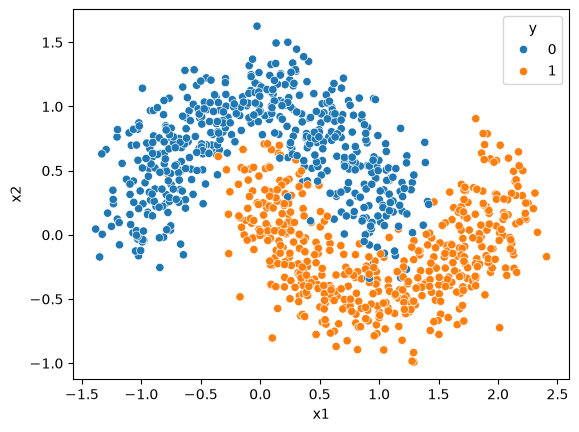

In [4]:
sns.scatterplot(x="x1",y="x2", data=dataset , hue="y")
plt.show()


In [6]:
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y, random_state=42 , test_size=0.2)

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [8]:
dt = DecisionTreeClassifier()
dt.fit(x_train , y_train)
dt.score(x_test , y_test)*100 , dt.score(x_train , y_train)*100 , dt.score(x_test , y_test)*100-dt.score(x_train , y_train)*100

(97.5, 100.0, -2.5)

In [9]:
sv = SVC()
sv.fit(x_train , y_train)
sv.score(x_test , y_test)*100 , sv.score(x_train , y_train)*100 , sv.score(x_test , y_test)*100-sv.score(x_train , y_train)*100

(98.0, 96.125, 1.875)

In [10]:
gnb = GaussianNB()
gnb.fit(x_train , y_train)
gnb.score(x_test , y_test)*100 , gnb.score(x_train , y_train)*100 , gnb.score(x_test , y_test)*100-gnb.score(x_train , y_train)*100

(84.0, 86.5, -2.5)

In [11]:
from sklearn.ensemble import VotingClassifier
li = [("dt1",DecisionTreeClassifier()),("sv1",SVC()),("gnb1",GaussianNB())]
vc = VotingClassifier(li) #weights = [10,4,7]
vc.fit(x_train , y_train)
vc.score(x_test , y_test)*100 , vc.score(x_train , y_train)*100 , vc.score(x_test , y_test)*100-vc.score(x_train , y_train)*100

(98.0, 96.625, 1.375)

In [12]:
#Check Classifier : Mode / Regressor : Avergaing or weightage

In [14]:
prd ={"dt":dt.predict(x_test),"svc":sv.predict(x_test),"gnb": gnb.predict(x_test),"vc":vc.predict(x_test)}
pd.DataFrame(prd)

,dt,svc,gnb,vc
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,1,1,1,1
4,1,1,1,1
...,...,...,...,...
195,1,1,1,1
196,0,0,0,0
197,1,1,1,1
198,1,1,1,1
